In [1]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.runner  import setup_scheduled_trainer, setup_dynamic_trainer
from ncpu.dataset import NCPUDataset

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

model_path = None

In [2]:
from ncpu.dataset import DynamicDataset
from ncpu.config import TINY_AND_TRAINING_CONFIG

BATCH_SIZE = 8
STEPS = 2_000
trainer = setup_dynamic_trainer(
    TINY_AND_TRAINING_CONFIG, 
    update_y = 1,
    update_x = 0,
    steps = STEPS*BATCH_SIZE
)


Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([8, 32, 32]) -> torch.Size([8, 32, 32])
  first_state: torch.Size([8, 16, 32, 32])
  rollout: torch.Size([8, 11, 16, 32, 32])
  loss: 0.018414534628391266
Sanity check completed successfully


# Learn GATE Logic

loss=0.000439:  95%|#########5| 1900/2000 [14:08<00:41,  2.42it/s]

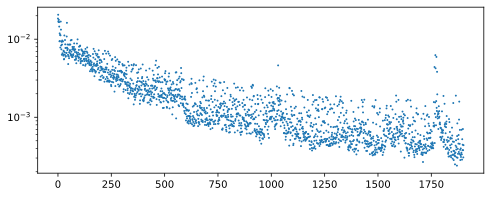

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.03, mean=0.07, std=0.25
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.16
nca_out: (8, 32, 32) torch.float32, min=-0.39, max=1.10, mean=0.05, std=0.19


,,,,,,,
,,,,,,,
,,,,,,,

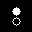
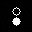
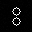
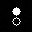
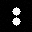
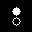
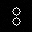
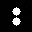
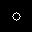
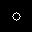
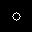
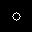
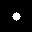
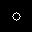
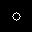
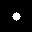
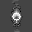
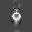
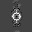
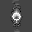
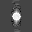
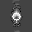
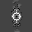
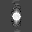

#0,#1,#2,#3,#4,#5,#6,#7

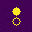
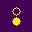
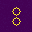
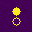
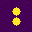
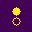
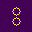
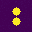

In [3]:
stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

# Learning Information Propagation

loss=0.000274:  18%|#7        | 3500/20000 [29:20<1:46:20,  2.59it/s]

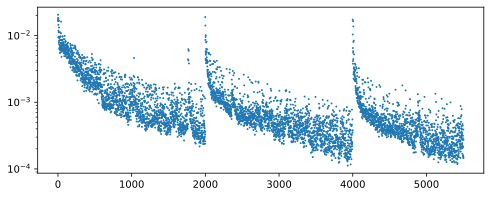

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.04, mean=0.07, std=0.26
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.16
nca_out: (8, 32, 32) torch.float32, min=-0.32, max=1.09, mean=0.04, std=0.18


,,,,,,,
,,,,,,,
,,,,,,,

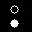
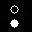
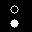
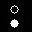
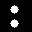
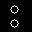
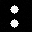
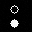
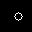
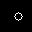
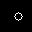
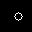
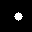
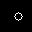
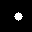
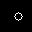
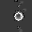
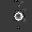
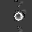
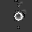
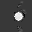
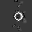
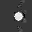
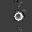

In [ ]:
stop_loss = 0.0001
N_evolutions = 10
pbar = tqdm(range(STEPS * N_evolutions))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break